# Advanced Task 1 — Term Deposit Subscription Prediction (Bank Marketing) + SHAP

## Objective
Predict whether a bank customer will subscribe to a term deposit (`y`) after a marketing campaign.

## What this notebook covers (requirements)
- Load + explore dataset
- Encode categorical features properly (One-Hot Encoding)
- Train models: Logistic Regression and Random Forest
- Evaluate: Confusion Matrix, F1-Score, ROC Curve
- Explain at least 5 predictions using SHAP (Explainable AI)

## Dataset
Bank Marketing Dataset (UCI)  
Preferred file names:
- `data/bank.csv` or `data/bank-full.csv`

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import urllib.request
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, roc_auc_score
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# -----------------------
# Repo / data / outputs
# -----------------------
def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / ".git").exists() or (p / "data").exists():
            return p
    return start

ROOT = find_repo_root()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs" / "adv_task1"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT   :", ROOT)
print("DATA   :", DATA_DIR)
print("OUTPUT :", OUT_DIR)

def save_fig(name: str) -> None:
    try:
        path = OUT_DIR / name
        plt.tight_layout()
        plt.savefig(path, dpi=150, bbox_inches="tight")
        print("Saved:", path)
    except Exception as e:
        print("Note: could not save figure:", e)

def read_csv_safely(path: Path) -> pd.DataFrame:
    # auto-detect separator (works for ',' and ';')
    return pd.read_csv(path, sep=None, engine="python")

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[ \-./]", "_", regex=True)
    )
    return df

ROOT   : f:\coding\DevelopersHub-Advanced-Tasks
DATA   : f:\coding\DevelopersHub-Advanced-Tasks\data
OUTPUT : f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task1


In [2]:
def find_bank_file(data_dir: Path) -> Path | None:
    candidates = sorted(data_dir.glob("*.csv"))
    # prefer bank-full if present
    for f in candidates:
        if f.name.lower() == "bank-full.csv":
            return f
    for f in candidates:
        if f.name.lower() == "bank.csv":
            return f
    # fallback: any csv containing bank
    for f in candidates:
        if "bank" in f.name.lower():
            return f
    return None

bank_path = find_bank_file(DATA_DIR)

if bank_path is None:
    # Auto-download a public mirror (small bank.csv)
    # Note: still UCI-style columns and target y yes/no.
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/bank.csv"
    bank_path = DATA_DIR / "bank.csv"
    print("No bank dataset found in data/. Auto-downloading to:", bank_path.name)
    urllib.request.urlretrieve(url, bank_path)

print("Using dataset:", bank_path)
df_raw = read_csv_safely(bank_path)
df = normalize_columns(df_raw)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Using dataset: f:\coding\DevelopersHub-Advanced-Tasks\data\bank.csv
Shape: (4521, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


Target distribution (raw):


y
no     4000
yes     521
Name: count, dtype: int64

,missing_%


Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task1\eda_age_distribution.png


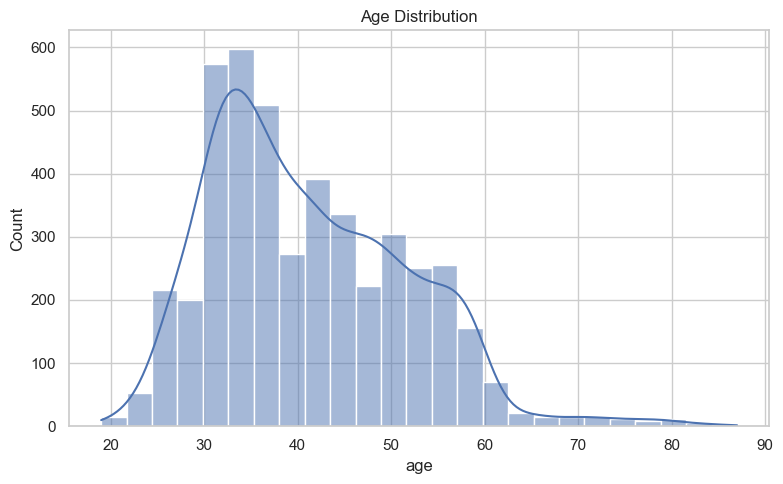

Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task1\eda_job_distribution.png


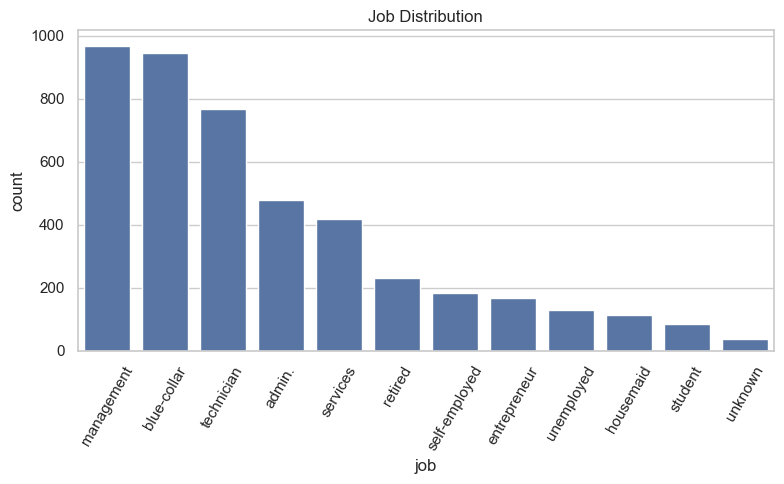

In [3]:
if "y" not in df.columns:
    raise ValueError(f"Target column 'y' not found. Available columns: {df.columns.tolist()}")

# Target distribution
print("Target distribution (raw):")
display(df["y"].value_counts(dropna=False))

# Missing values
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
display(missing_pct[missing_pct > 0].to_frame("missing_%"))

# Simple plots (basic EDA)
if "age" in df.columns:
    sns.histplot(df["age"].dropna(), bins=25, kde=True)
    plt.title("Age Distribution")
    save_fig("eda_age_distribution.png")
    plt.show()

if "job" in df.columns:
    sns.countplot(data=df, x="job", order=df["job"].value_counts().index)
    plt.xticks(rotation=60)
    plt.title("Job Distribution")
    save_fig("eda_job_distribution.png")
    plt.show()

In [4]:
X = df.drop(columns=["y"]).copy()

y_raw = df["y"].astype(str).str.strip().str.lower()
y = y_raw.map({"yes": 1, "no": 0})

if y.isna().any():
    raise ValueError(f"Unexpected values in y. Unique values: {sorted(y_raw.unique().tolist())}")

print("X shape:", X.shape)
print("y mean (subscription rate):", round(y.mean(), 4))

X shape: (4521, 16)
y mean (subscription rate): 0.1152


In [5]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=4000))
])

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

logreg_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.



Logistic Regression
F1-score: 0.4
Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task1\cm_logistic_regression.png


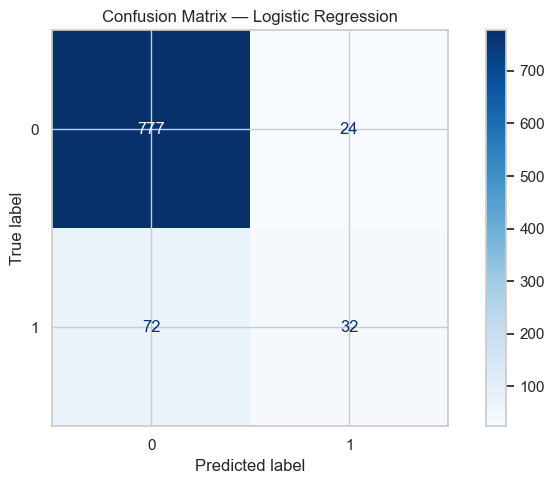

ROC-AUC: 0.8905
Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task1\roc_logistic_regression.png


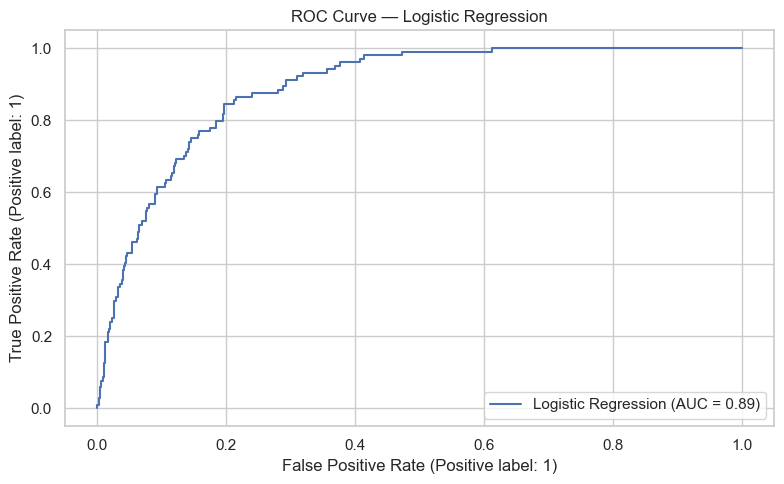


Random Forest
F1-score: 0.2727
Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task1\cm_random_forest.png


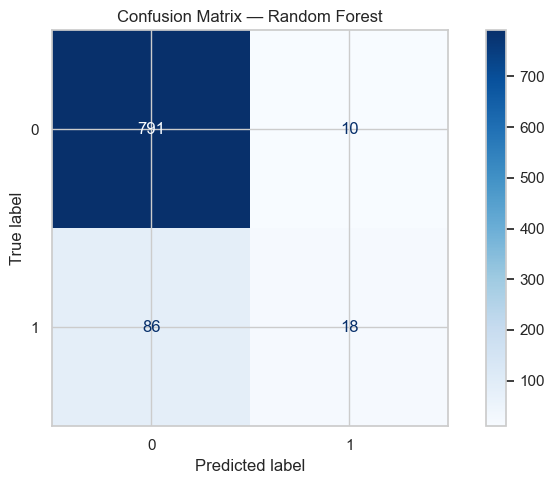

ROC-AUC: 0.9086
Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task1\roc_random_forest.png


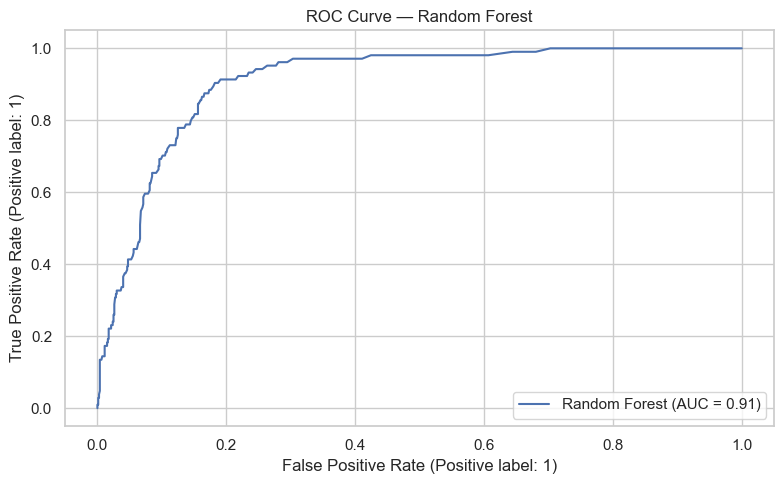

In [6]:
def evaluate_classifier(name: str, model: Pipeline):
    pred = model.predict(X_test)
    f1 = f1_score(y_test, pred)
    print(f"\n{name}")
    print("F1-score:", round(f1, 4))

    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    save_fig(f"cm_{name.lower().replace(' ', '_')}.png")
    plt.show()

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)
        print("ROC-AUC:", round(auc, 4))

        RocCurveDisplay.from_predictions(y_test, proba, name=name)
        plt.title(f"ROC Curve — {name}")
        save_fig(f"roc_{name.lower().replace(' ', '_')}.png")
        plt.show()

evaluate_classifier("Logistic Regression", logreg_pipe)
evaluate_classifier("Random Forest", rf_pipe)

## SHAP Explanations (Explain at least 5 predictions)

We will explain predictions of the **Random Forest** model using SHAP.

Notes:
- We use the fitted preprocessing step from the pipeline (no `preprocess not defined` issue).
- We explain 5 test samples with waterfall plots.

SHAP version: 0.49.1

Explanation 1 | test_row=70 | actual=1 | prob=0.1740 | pred=0


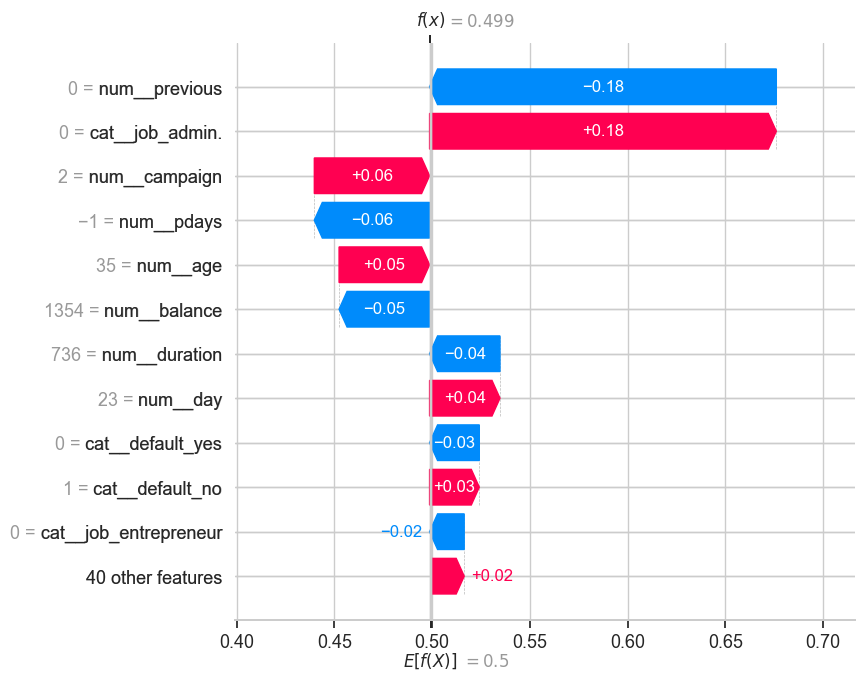


Explanation 2 | test_row=457 | actual=1 | prob=0.1240 | pred=0


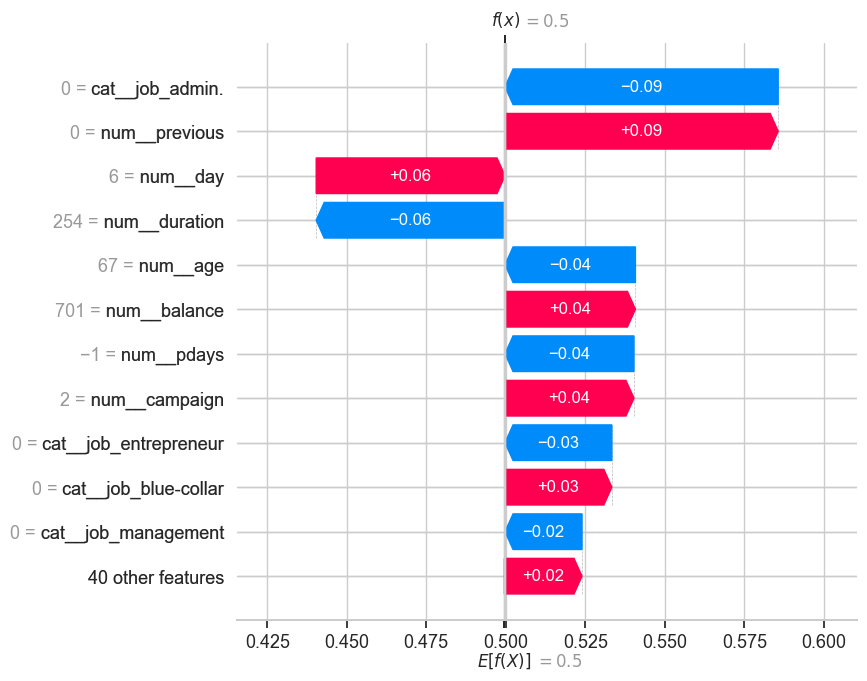


Explanation 3 | test_row=218 | actual=0 | prob=0.0000 | pred=0


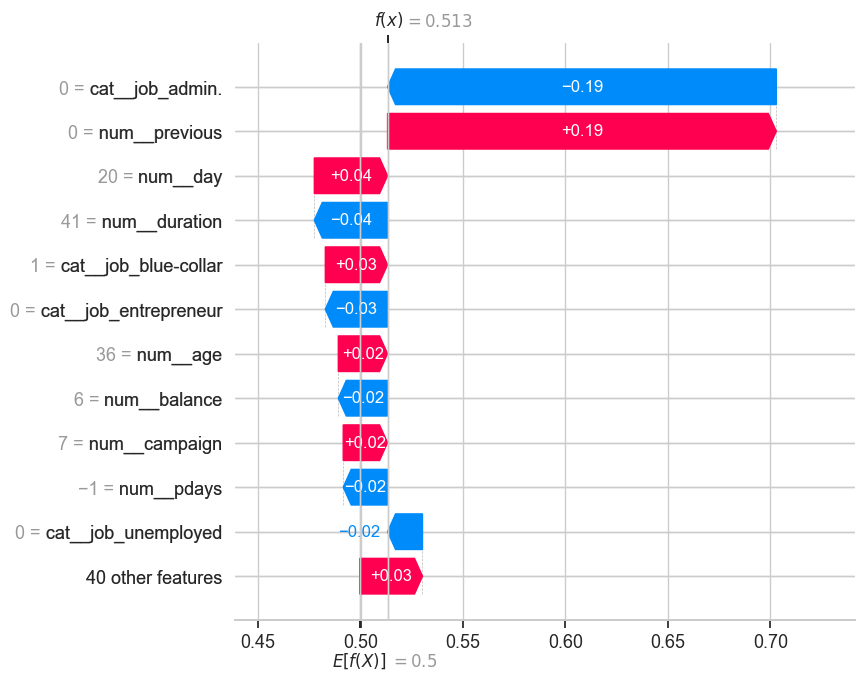


Explanation 4 | test_row=250 | actual=0 | prob=0.5340 | pred=1


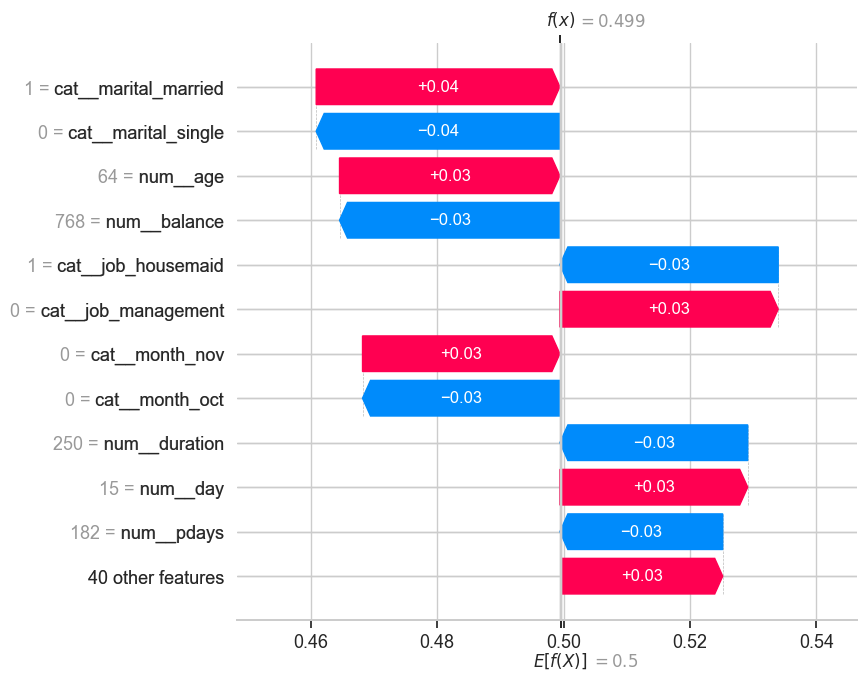


Explanation 5 | test_row=39 | actual=0 | prob=0.1040 | pred=0


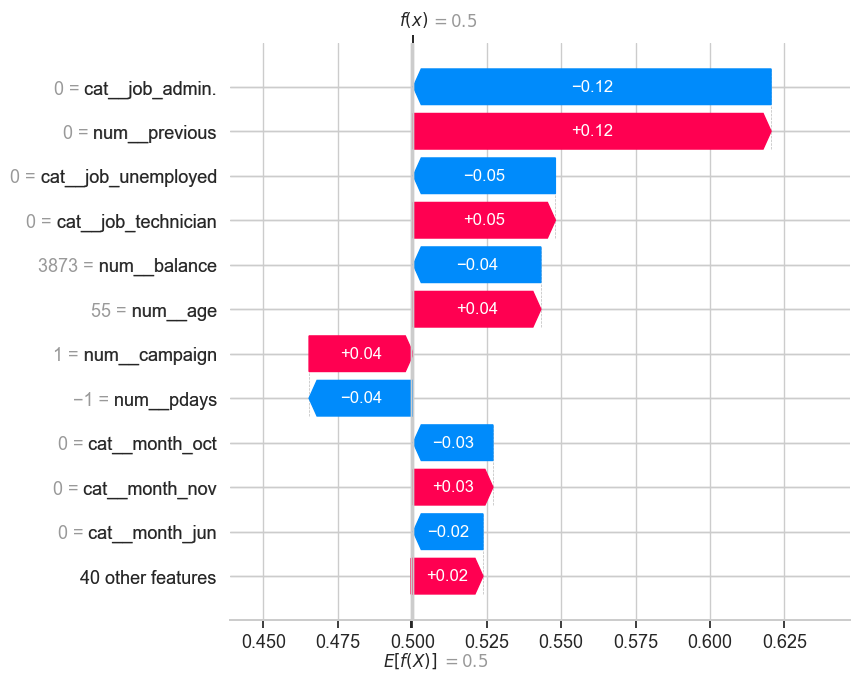

In [8]:
# --- SHAP ---
# Run this AFTER rf_pipe has been trained and X_train/X_test/y_test exist.

import numpy as np

try:
    import shap
    print("SHAP version:", shap.__version__)
except ImportError:
    raise ImportError("Install SHAP first: pip install shap")

# 1) Use fitted preprocess + trained RF directly from the pipeline (no 'preprocess' NameError)
preprocess_fitted = rf_pipe.named_steps["preprocess"]
rf_model = rf_pipe.named_steps["model"]

# 2) Transform X_test
X_test_t = preprocess_fitted.transform(X_test)

# 3) Pick up to 5 test rows
n = X_test.shape[0]
k = min(5, n)
idx = np.random.RandomState(42).choice(n, size=k, replace=False)

# 4) Convert selected rows to dense (safe for SHAP + plotting)
if hasattr(X_test_t, "toarray"):
    X_explain = X_test_t[idx].toarray()
else:
    X_explain = np.asarray(X_test_t[idx])

# 5) Feature names (best effort)
try:
    feature_names = preprocess_fitted.get_feature_names_out()
except Exception:
    feature_names = np.array([f"f{i}" for i in range(X_explain.shape[1])], dtype=object)

feature_names = np.array(feature_names, dtype=object).ravel()

# 6) SHAP TreeExplainer
explainer = shap.TreeExplainer(rf_model)

# SHAP values (binary classifier often returns list -> choose positive class = 1)
shap_out = explainer.shap_values(X_explain)
if isinstance(shap_out, list):
    shap_matrix = np.asarray(shap_out[1])  # shape: (k, n_features)
    expected = explainer.expected_value[1]
else:
    shap_matrix = np.asarray(shap_out)
    expected = explainer.expected_value

# base value MUST be a scalar float for waterfall in many SHAP versions
base_scalar = float(np.array(expected).ravel()[0])

# Also get predicted probabilities for reporting
proba_all = rf_pipe.predict_proba(X_test)[:, 1]

# 7) Plot explanations (waterfall) for k predictions with safe shape alignment + fallback
for i in range(k):
    row_index = int(idx[i])
    actual = int(y_test.iloc[row_index])
    prob = float(proba_all[row_index])
    pred_label = int(prob >= 0.5)

    print(f"\nExplanation {i+1} | test_row={row_index} | actual={actual} | prob={prob:.4f} | pred={pred_label}")

    vals_1d = np.array(shap_matrix[i]).ravel()
    data_1d = np.array(X_explain[i]).ravel()
    names_1d = np.array(feature_names, dtype=object).ravel()

    # Align lengths safely (prevents ValueError due to mismatch)
    m = min(len(vals_1d), len(data_1d), len(names_1d))
    vals_1d, data_1d, names_1d = vals_1d[:m], data_1d[:m], names_1d[:m]

    exp = shap.Explanation(
        values=vals_1d,
        base_values=base_scalar,
        data=data_1d,
        feature_names=list(names_1d)
    )

    try:
        shap.plots.waterfall(exp, max_display=12)
    except Exception as e:
        print("waterfall failed -> using legacy shap.waterfall_plot. Reason:", e)
        shap.waterfall_plot(
            base_scalar,
            vals_1d,
            features=data_1d,
            feature_names=list(names_1d),
            max_display=12
        )

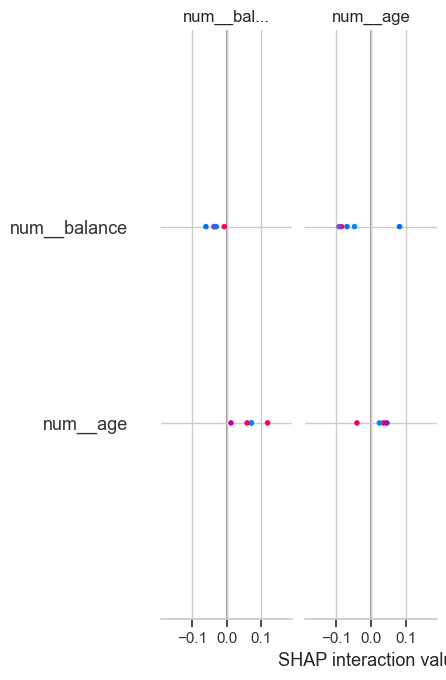

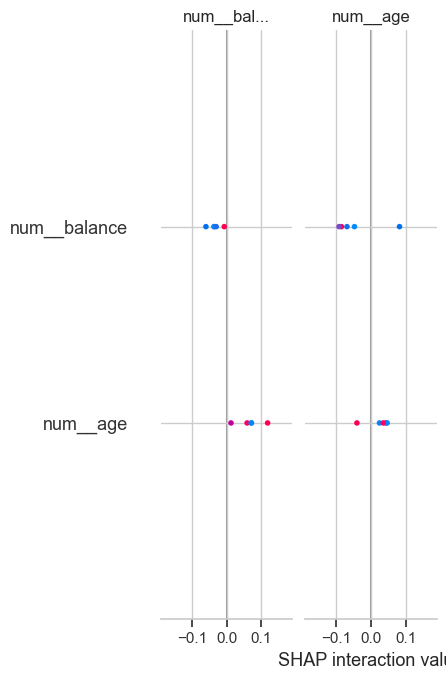

In [11]:
try:
    # Global feature importance (bar)
    shap.summary_plot(
        shap_matrix,
        features=X_explain,
        feature_names=feature_names,
        plot_type="bar",
        show=True
    )
except Exception as e:
    print("SHAP summary bar plot skipped. Reason:", e)

try:
    # Beeswarm (more detailed)
    shap.summary_plot(
        shap_matrix,
        features=X_explain,
        feature_names=feature_names,
        show=True
    )
except Exception as e:
    print("SHAP beeswarm plot skipped. Reason:", e)

## Global Explainability (SHAP Summary)

Waterfall plots explain individual predictions.  
Now we will generate global explanations to see which features matter most overall.

If the plot fails due to SHAP version differences, the notebook will skip safely.

## Model Comparison Summary

We trained two models:
- Logistic Regression (baseline)
- Random Forest (stronger non-linear model)

Now we will create a small comparison table (F1-score and ROC-AUC) to decide the final model.

In [10]:
from sklearn.metrics import f1_score, roc_auc_score

def get_metrics(model, X_te, y_te):
    pred = model.predict(X_te)
    f1 = f1_score(y_te, pred)

    auc = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, proba)

    return f1, auc

metrics = []
for name, mdl in [("Logistic Regression", logreg_pipe), ("Random Forest", rf_pipe)]:
    f1, auc = get_metrics(mdl, X_test, y_test)
    metrics.append({"model": name, "f1": f1, "roc_auc": auc})

metrics_df = pd.DataFrame(metrics).sort_values("f1", ascending=False)
display(metrics_df)

,model,f1,roc_auc
0,Logistic Regression,0.400000,0.890497
1,Random Forest,0.272727,0.908558


## Explainability Output Table (5 Predictions)

This table documents the 5 explained predictions:
- actual label
- predicted probability
- predicted class

This is useful for report/submission.

In [12]:
# idx was created in SHAP cell (the 5 selected test rows)
rows = []
for i in range(k):
    row_index = int(idx[i])
    rows.append({
        "test_row_index": row_index,
        "actual_y": int(y_test.iloc[row_index]),
        "pred_prob": float(proba_all[row_index]),
        "pred_label_(thr=0.5)": int(proba_all[row_index] >= 0.5)
    })

explain_table = pd.DataFrame(rows)
display(explain_table)

,test_row_index,actual_y,pred_prob,pred_label_(thr=0.5)
0,70,1,0.174,0
1,457,1,0.124,0
2,218,0,0.000,0
3,250,0,0.534,1
4,39,0,0.104,0


## Business Insight (Customer Behavior)

We will analyze acceptance rate (subscription rate) by a few customer groups
(e.g., job, marital, education) to produce business-friendly findings.

In [13]:
df_analysis = df.copy()
df_analysis["y01"] = y.values  # 0/1 mapped target

def subscription_rate_by(col: str):
    if col not in df_analysis.columns:
        print(f"Skipped: '{col}' not found.")
        return
    out = (df_analysis.groupby(col)["y01"]
           .agg(["count", "mean"])
           .rename(columns={"count": "n", "mean": "subscription_rate"})
           .sort_values("subscription_rate", ascending=False))
    display(out)

subscription_rate_by("job")
subscription_rate_by("marital")
subscription_rate_by("education")

,n,subscription_rate
job,,
retired,230,0.234783
student,84,0.226190
unknown,38,0.184211
management,969,0.135191
housemaid,112,0.125000
admin.,478,0.121339
self-employed,183,0.109290
technician,768,0.108073
unemployed,128,0.101562


,n,subscription_rate
marital,,
divorced,528,0.145833
single,1196,0.139632
married,2797,0.099035


,n,subscription_rate
education,,
tertiary,1350,0.142963
secondary,2306,0.106245
unknown,187,0.101604
primary,678,0.094395


## Conclusion

Write in simple English:
- Which model performed better (based on F1 and ROC-AUC)?
- What does the confusion matrix indicate (where mistakes happen)?
- What SHAP shows for key drivers (top factors increasing/decreasing subscription probability)?
- Business recommendation: which segments to target and why.

In [14]:
import joblib

# Choose best model (example: Random Forest)
best_model = rf_pipe

model_path = OUT_DIR / "best_model.joblib"
joblib.dump(best_model, model_path)
print("Saved model to:", model_path)

Saved model to: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task1\best_model.joblib
